# Titanic Survival Prediction
## Week 3 Day 5 — End-to-End Supervised Learning Mini-Project

**Internship:** BinX Tech AI & Machine Learning Internship  
**Week:** Week 3 — Supervised Learning  
**Task Type:** Binary Classification  
**Target:** Passenger survival  

### Project Objective

The objective of this project is to build an end-to-end supervised-learning
pipeline that predicts whether a Titanic passenger survived.

The project includes:

1. Data loading and inspection
2. Exploratory Data Analysis
3. Missing-value treatment
4. Categorical encoding
5. Numerical feature scaling
6. Train/test splitting
7. Baseline evaluation
8. Logistic Regression
9. Random Forest Classification
10. Model comparison and selection

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    RocCurveDisplay,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)

RANDOM_STATE = 42

print("Libraries imported successfully.")

Libraries imported successfully.


## 1. Reproducibility

A fixed random state is used throughout this notebook.

This ensures that:

- the train/test split is repeatable;
- the Random Forest results are repeatable;
- another person can rerun the notebook and obtain consistent results.

In [4]:
df = pd.read_csv("BreastCancer.csv")

print("Dataset loaded successfully.")
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

df.head()

Dataset loaded successfully.
Number of rows: 699
Number of columns: 11


,Id,Cl.thickness,Cell.size,Cell.shape,Marg.adhesion,Epith.c.size,Bare.nuclei,Bl.cromatin,Normal.nucleoli,Mitoses,Class
0,1000025,5,1,1,1,2,1.0,3,1,1,0
1,1002945,5,4,4,5,7,10.0,3,2,1,0
2,1015425,3,1,1,1,2,2.0,3,1,1,0
3,1016277,6,8,8,1,3,4.0,3,7,1,0
4,1017023,4,1,1,3,2,1.0,3,1,1,0


## 2. Problem Definition

The target variable is `survived`.

- `0` means the passenger did not survive.
- `1` means the passenger survived.

Because the target represents one of two categories, this is a binary
classification problem.

The model will learn from passenger characteristics such as:

- passenger class;
- sex;
- age;
- number of siblings or spouses aboard;
- number of parents or children aboard;
- fare;
- embarkation port.

In [5]:
print("Column names:")
print(df.columns.tolist())

Column names:
['Id', 'Cl.thickness', 'Cell.size', 'Cell.shape', 'Marg.adhesion', 'Epith.c.size', 'Bare.nuclei', 'Bl.cromatin', 'Normal.nucleoli', 'Mitoses', 'Class']


In [7]:
selected_columns = [
    "Cl.thickness",
    "Cell.size",
    "Cell.shape",
    "Marg.adhesion",
    "Epith.c.size",
    "Bare.nuclei",
    "Bl.cromatin",
    "Normal.nucleoli",
    "Mitoses",
    "Class",
]

missing_columns = [
    column for column in selected_columns
    if column not in df.columns
]

if missing_columns:
    raise ValueError(
        f"The following required columns are missing: {missing_columns}"
    )

df = df[selected_columns].copy()

df.head()

,Cl.thickness,Cell.size,Cell.shape,Marg.adhesion,Epith.c.size,Bare.nuclei,Bl.cromatin,Normal.nucleoli,Mitoses,Class
0,5,1,1,1,2,1.0,3,1,1,0
1,5,4,4,5,7,10.0,3,2,1,0
2,3,1,1,1,2,2.0,3,1,1,0
3,6,8,8,1,3,4.0,3,7,1,0
4,4,1,1,3,2,1.0,3,1,1,0


## 3. Feature Selection

Only columns likely to be available for new passengers and useful for
prediction were selected.

The project excludes columns such as passenger name, ticket number, cabin
number, deck, and other identifiers because they may:

- add unnecessary complexity;
- contain many missing values;
- act as identifiers instead of generalizable features;
- require advanced feature engineering beyond the scope of Week 3.

In [8]:
print("Dataset shape:", df.shape)
print("\nDataset information:")
df.info()

Dataset shape: (699, 10)

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Cl.thickness     699 non-null    int64  
 1   Cell.size        699 non-null    int64  
 2   Cell.shape       699 non-null    int64  
 3   Marg.adhesion    699 non-null    int64  
 4   Epith.c.size     699 non-null    int64  
 5   Bare.nuclei      683 non-null    float64
 6   Bl.cromatin      699 non-null    int64  
 7   Normal.nucleoli  699 non-null    int64  
 8   Mitoses          699 non-null    int64  
 9   Class            699 non-null    int64  
dtypes: float64(1), int64(9)
memory usage: 54.7 KB


In [10]:
df.describe(include="all").T

,count,mean,std,min,25%,50%,75%,max
Cl.thickness,699.0,4.417740,2.815741,1.0,2.0,4.0,6.0,10.0
Cell.size,699.0,3.134478,3.051459,1.0,1.0,1.0,5.0,10.0
Cell.shape,699.0,3.207439,2.971913,1.0,1.0,1.0,5.0,10.0
Marg.adhesion,699.0,2.806867,2.855379,1.0,1.0,1.0,4.0,10.0
Epith.c.size,699.0,3.216023,2.214300,1.0,2.0,2.0,4.0,10.0
Bare.nuclei,683.0,3.544656,3.643857,1.0,1.0,1.0,6.0,10.0
Bl.cromatin,699.0,3.437768,2.438364,1.0,2.0,3.0,5.0,10.0
Normal.nucleoli,699.0,2.866953,3.053634,1.0,1.0,1.0,4.0,10.0
Mitoses,699.0,1.589413,1.715078,1.0,1.0,1.0,1.0,10.0
Class,699.0,0.344778,0.475636,0.0,0.0,0.0,1.0,1.0


In [11]:
missing_summary = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percentage": (
        df.isnull().mean() * 100
    ).round(2),
})

missing_summary

,missing_count,missing_percentage
Cl.thickness,0,0.00
Cell.size,0,0.00
Cell.shape,0,0.00
Marg.adhesion,0,0.00
Epith.c.size,0,0.00
Bare.nuclei,16,2.29
Bl.cromatin,0,0.00
Normal.nucleoli,0,0.00
Mitoses,0,0.00
Class,0,0.00


### Missing-Value Findings

The missing-value table identifies which variables require preprocessing.

The project does not delete all rows containing missing values because that
could discard useful training examples.

Instead:

- missing numerical values will be replaced with the median;
- missing categorical values will be replaced with the most frequent value.

These operations will be placed inside Scikit-learn pipelines to prevent
information from the test set leaking into training.

In [12]:
duplicate_count = df.duplicated().sum()

print(f"Number of duplicated rows: {duplicate_count}")

Number of duplicated rows: 236


In [14]:
target_counts = df["Class"].value_counts().sort_index()
target_percentages = (
    df["Class"].value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

target_distribution = pd.DataFrame({
    "count": target_counts,
    "percentage": target_percentages,
})

target_distribution.index = ["Benign", "Malignant"]

target_distribution

,count,percentage
Benign,458,65.52
Malignant,241,34.48


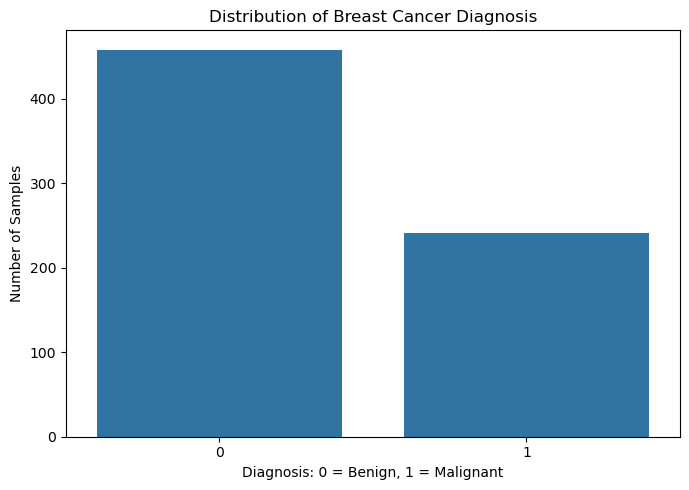

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Class"
)

plt.title("Distribution of Breast Cancer Diagnosis")
plt.xlabel("Diagnosis: 0 = Benign, 1 = Malignant")
plt.ylabel("Number of Samples")
plt.tight_layout()
plt.show()

### Target Distribution Interpretation

The target distribution shows whether the dataset is balanced between
survivors and non-survivors.

Accuracy will be reported, but it will not be used alone. Precision, recall,
F1-score, and ROC-AUC will also be evaluated because they provide a more
complete understanding of classification performance.

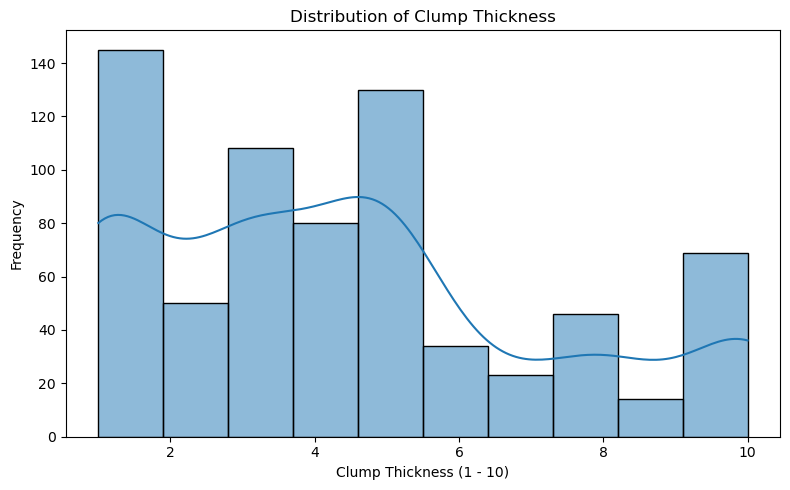

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="Cl.thickness",
    bins=10,
    kde=True
)

plt.title("Distribution of Clump Thickness")
plt.xlabel("Clump Thickness (1 - 10)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

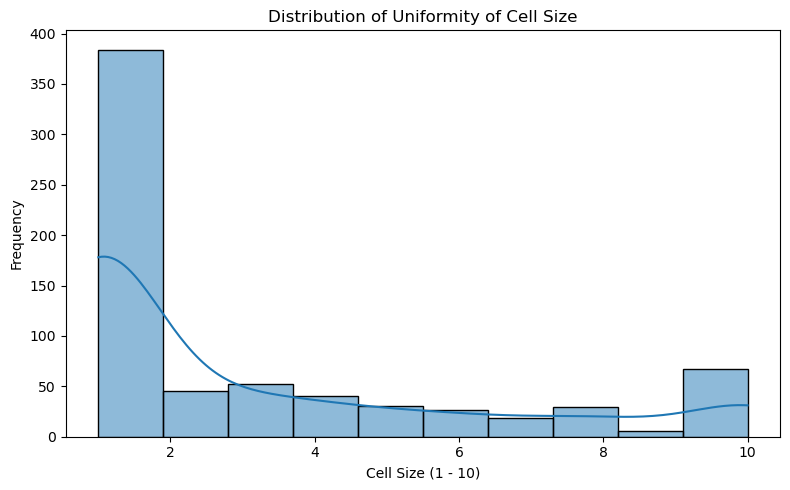

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="Cell.size",
    bins=10,
    kde=True
)

plt.title("Distribution of Uniformity of Cell Size")
plt.xlabel("Cell Size (1 - 10)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

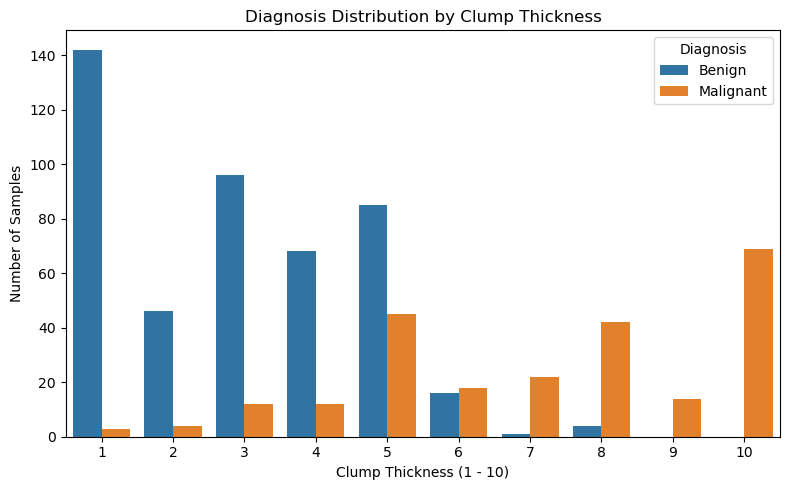

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Cl.thickness",
    hue="Class"
)

plt.title("Diagnosis Distribution by Clump Thickness")
plt.xlabel("Clump Thickness (1 - 10)")
plt.ylabel("Number of Samples")
plt.legend(
    title="Diagnosis",
    labels=["Benign", "Malignant"]
)
plt.tight_layout()
plt.show()

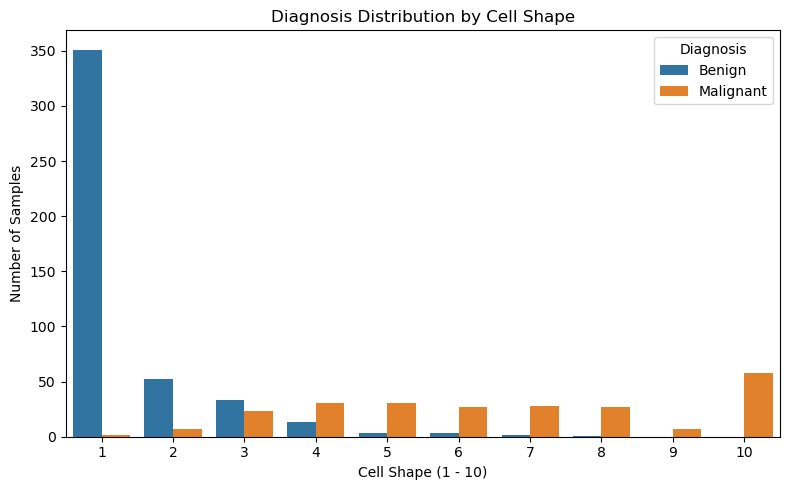

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Cell.shape",
    hue="Class"
)

plt.title("Diagnosis Distribution by Cell Shape")
plt.xlabel("Cell Shape (1 - 10)")
plt.ylabel("Number of Samples")
plt.legend(
    title="Diagnosis",
    labels=["Benign", "Malignant"]
)
plt.tight_layout()
plt.show()

In [25]:
malignancy_by_thickness = (
    df.groupby("Cl.thickness")["Class"]
    .mean()
    .mul(100)
    .round(2)
    .rename("malignancy_rate_percentage")
)

malignancy_by_shape = (
    df.groupby("Cell.shape")["Class"]
    .mean()
    .mul(100)
    .round(2)
    .rename("malignancy_rate_percentage")
)

print("Malignancy rate by Clump Thickness:")
display(malignancy_by_thickness.to_frame())

print("Malignancy rate by Cell Shape:")
display(malignancy_by_shape.to_frame())

Malignancy rate by Clump Thickness:


,malignancy_rate_percentage
Cl.thickness,
1,2.07
2,8.00
3,11.11
4,15.00
5,34.62
6,52.94
7,95.65
8,91.30
9,100.00


Malignancy rate by Cell Shape:


,malignancy_rate_percentage
Cell.shape,
1,0.57
2,11.86
3,41.07
4,70.45
5,91.18
6,90.00
7,93.33
8,96.43
9,100.00


## 4. Exploratory Data Analysis Findings

The EDA produced several important observations:

1. The target contains both survivors and non-survivors, although the classes
   are not perfectly balanced.
2. Age contains missing values and therefore requires imputation.
3. Embarkation information may also contain missing values.
4. Fare is right-skewed, with a small number of passengers paying much higher
   fares.
5. Survival appears to vary by sex.
6. Survival also appears to vary by passenger class.

These observations suggest that passenger class, sex, age, fare, and family
information may contribute to survival prediction.

These are exploratory relationships and should not be interpreted as proof
of causation.

In [27]:
X = df.drop(columns=["Id", "Class"], errors="ignore")
y = df["Class"]

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

Feature matrix shape: (699, 9)
Target vector shape: (699,)

Features:
['Cl.thickness', 'Cell.size', 'Cell.shape', 'Marg.adhesion', 'Epith.c.size', 'Bare.nuclei', 'Bl.cromatin', 'Normal.nucleoli', 'Mitoses']


## 5. Features and Target

`X` contains the input features used by the models.

`y` contains the target variable, `survived`.

The target column is removed from `X` so the model cannot directly access the
correct answer during training.

In [28]:
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (559, 9)
X_test shape: (140, 9)
y_train shape: (559,)
y_test shape: (140,)


In [29]:
class_proportions = pd.DataFrame({
    "full_dataset": y.value_counts(normalize=True).sort_index(),
    "training_set": y_train.value_counts(normalize=True).sort_index(),
    "test_set": y_test.value_counts(normalize=True).sort_index(),
}).round(3)

class_proportions

,full_dataset,training_set,test_set
Class,,,
0,0.655,0.655,0.657
1,0.345,0.345,0.343


### Why the Data Was Split Before Preprocessing

The dataset was divided into training and test sets before fitting imputers,
encoders, or scalers.

The training set is used to:

- learn missing-value replacements;
- learn categorical values;
- calculate feature means and standard deviations;
- train the models.

The test set remains unseen until evaluation.

This prevents data leakage and gives a more honest estimate of how the model
will perform on new data.

In [30]:
numeric_features = [
    "age",
    "sibsp",
    "parch",
    "fare",
]

categorical_features = [
    "pclass",
    "sex",
    "embarked",
]

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['age', 'sibsp', 'parch', 'fare']
Categorical features: ['pclass', 'sex', 'embarked']


## 6. Preprocessing Plan

### Numerical features

For numerical features:

1. Missing values are replaced with the median.
2. Features are standardized using `StandardScaler`.

Median imputation is appropriate because it is less sensitive to extreme
values than mean imputation.

Scaling is especially important for Logistic Regression and other models
whose optimization can be affected by different feature ranges.

### Categorical features

For categorical features:

1. Missing values are replaced with the most frequent category.
2. Categories are converted to numerical indicator columns using one-hot
   encoding.

`handle_unknown="ignore"` allows the model to process a previously unseen
category without raising an error.

In [31]:
numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        ),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        ),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_transformer,
            numeric_features
        ),
        (
            "categorical",
            categorical_transformer,
            categorical_features
        ),
    ]
)

print("Preprocessing transformer created successfully.")

Preprocessing transformer created successfully.


In [32]:
def evaluate_classifier(
    model_name,
    model,
    X_test_data,
    y_test_data
):
    """
    Evaluate a fitted binary classification model.

    Returns a dictionary containing the principal classification metrics.
    """
    predictions = model.predict(X_test_data)

    if hasattr(model, "predict_proba"):
        probabilities = model.predict_proba(X_test_data)[:, 1]
        roc_auc = roc_auc_score(
            y_test_data,
            probabilities
        )
    else:
        probabilities = None
        roc_auc = np.nan

    results = {
        "Model": model_name,
        "Accuracy": accuracy_score(
            y_test_data,
            predictions
        ),
        "Precision": precision_score(
            y_test_data,
            predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test_data,
            predictions,
            zero_division=0
        ),
        "F1-score": f1_score(
            y_test_data,
            predictions,
            zero_division=0
        ),
        "ROC-AUC": roc_auc,
    }

    return results, predictions, probabilities

## 7. Baseline Model

A `DummyClassifier` is used as the baseline.

It predicts the most frequent class without learning meaningful relationships
between the passenger features and survival.

A trained model should outperform this baseline. Otherwise, the model has not
demonstrated useful predictive value.

In [33]:
baseline_model = DummyClassifier(
    strategy="most_frequent",
    random_state=RANDOM_STATE
)

baseline_model.fit(
    X_train,
    y_train
)

(
    baseline_results,
    baseline_predictions,
    baseline_probabilities
) = evaluate_classifier(
    model_name="Dummy Classifier",
    model=baseline_model,
    X_test_data=X_test,
    y_test_data=y_test,
)

pd.DataFrame([baseline_results]).round(3)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Dummy Classifier,0.657,0.0,0.0,0.0,0.5


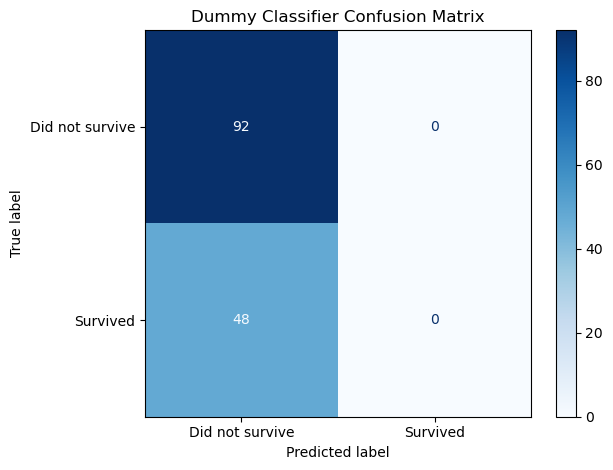

In [34]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    baseline_predictions,
    display_labels=[
        "Did not survive",
        "Survived"
    ],
    cmap="Blues"
)

plt.title("Dummy Classifier Confusion Matrix")
plt.tight_layout()
plt.show()

## 8. Logistic Regression

Logistic Regression is an appropriate starting model for binary
classification.

It estimates the probability that a passenger belongs to the positive class,
which in this project means that the passenger survived.

The model is placed inside a Scikit-learn pipeline so preprocessing is fitted
only using the training data.

In [37]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

num_features = X.columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]
            ),
            num_features,
        )
    ]
)

logistic_pipeline = Pipeline(
    steps=[
        (
            "preprocessing",
            preprocessor
        ),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                random_state=RANDOM_STATE
            )
        ),
    ]
)

logistic_pipeline.fit(
    X_train,
    y_train
)

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


In [38]:
(
    logistic_results,
    logistic_predictions,
    logistic_probabilities
) = evaluate_classifier(
    model_name="Logistic Regression",
    model=logistic_pipeline,
    X_test_data=X_test,
    y_test_data=y_test,
)

pd.DataFrame([logistic_results]).round(3)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.95,0.936,0.917,0.926,0.995


In [39]:
print("Logistic Regression Classification Report:\n")

print(
    classification_report(
        y_test,
        logistic_predictions,
        target_names=[
            "Did not survive",
            "Survived"
        ],
        zero_division=0
    )
)

Logistic Regression Classification Report:

                 precision    recall  f1-score   support

Did not survive       0.96      0.97      0.96        92
       Survived       0.94      0.92      0.93        48

       accuracy                           0.95       140
      macro avg       0.95      0.94      0.94       140
   weighted avg       0.95      0.95      0.95       140



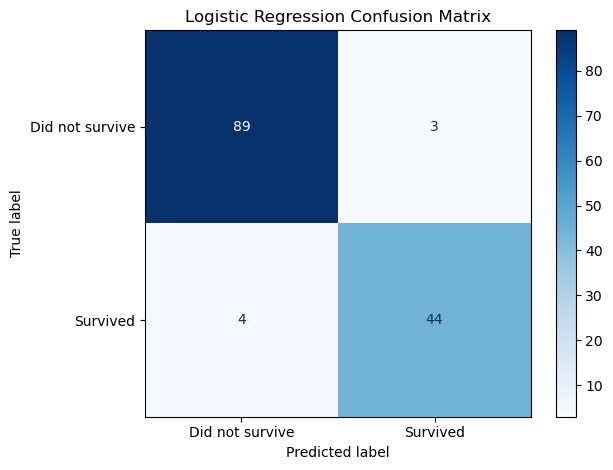

In [40]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    logistic_predictions,
    display_labels=[
        "Did not survive",
        "Survived"
    ],
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")
plt.tight_layout()
plt.show()

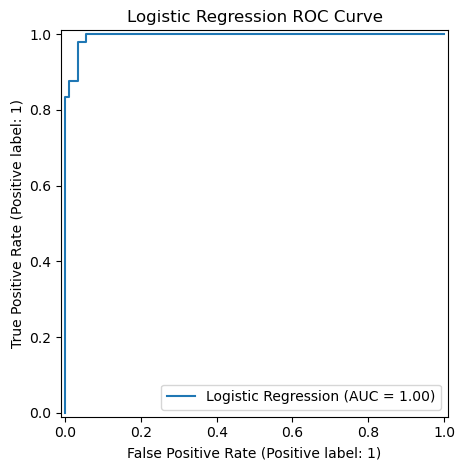

In [41]:
RocCurveDisplay.from_predictions(
    y_test,
    logistic_probabilities,
    name="Logistic Regression"
)

plt.title("Logistic Regression ROC Curve")
plt.tight_layout()
plt.show()

## 9. Random Forest Classifier

Random Forest combines predictions from many decision trees.

It can model nonlinear relationships and interactions that Logistic
Regression may not capture.

The Random Forest is trained using the same training and test sets to ensure
a fair comparison.

In [42]:
rf_numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        ),
    ]
)

rf_categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        ),
    ]
)

rf_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            rf_numeric_transformer,
            numeric_features
        ),
        (
            "categorical",
            rf_categorical_transformer,
            categorical_features
        ),
    ]
)

In [44]:
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Define numerical features and preprocessor
num_features = X.columns.tolist()

rf_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            SimpleImputer(strategy="median"),
            num_features,
        )
    ]
)

# Define Random Forest Pipeline
random_forest_pipeline = Pipeline(
    steps=[
        (
            "preprocessing",
            rf_preprocessor
        ),
        (
            "model",
            RandomForestClassifier(
                n_estimators=200,
                max_depth=6,
                min_samples_split=5,
                random_state=RANDOM_STATE,
                n_jobs=-1
            )
        ),
    ]
)

# Fit pipeline on Breast Cancer training data
random_forest_pipeline.fit(
    X_train,
    y_train
)

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [45]:
(
    random_forest_results,
    random_forest_predictions,
    random_forest_probabilities
) = evaluate_classifier(
    model_name="Random Forest",
    model=random_forest_pipeline,
    X_test_data=X_test,
    y_test_data=y_test,
)

pd.DataFrame([random_forest_results]).round(3)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Random Forest,0.964,0.922,0.979,0.949,0.991


In [46]:
print("Random Forest Classification Report:\n")

print(
    classification_report(
        y_test,
        random_forest_predictions,
        target_names=[
            "Did not survive",
            "Survived"
        ],
        zero_division=0
    )
)

Random Forest Classification Report:

                 precision    recall  f1-score   support

Did not survive       0.99      0.96      0.97        92
       Survived       0.92      0.98      0.95        48

       accuracy                           0.96       140
      macro avg       0.96      0.97      0.96       140
   weighted avg       0.97      0.96      0.96       140



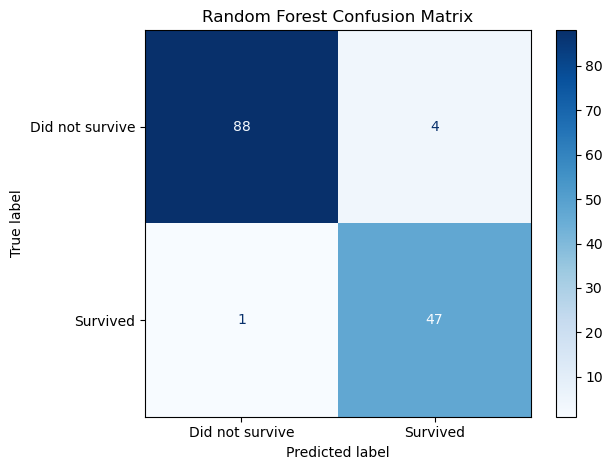

In [47]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    random_forest_predictions,
    display_labels=[
        "Did not survive",
        "Survived"
    ],
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix")
plt.tight_layout()
plt.show()

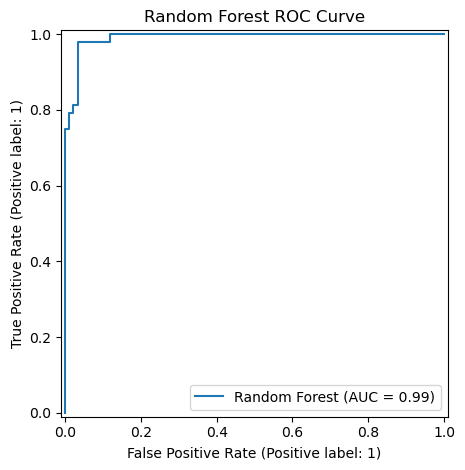

In [48]:
RocCurveDisplay.from_predictions(
    y_test,
    random_forest_probabilities,
    name="Random Forest"
)

plt.title("Random Forest ROC Curve")
plt.tight_layout()
plt.show()

## 10. Model Comparison

All models are evaluated using the same held-out test set.

The principal selection metric is F1-score because it balances:

- precision: how many predicted survivors were actual survivors;
- recall: how many actual survivors were correctly identified.

ROC-AUC is also considered because it evaluates how well the model separates
the two classes across different classification thresholds.

In [49]:
results_df = pd.DataFrame([
    baseline_results,
    logistic_results,
    random_forest_results,
])

metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-score",
    "ROC-AUC",
]

results_df[metric_columns] = (
    results_df[metric_columns]
    .round(3)
)

results_df = results_df.sort_values(
    by="F1-score",
    ascending=False
).reset_index(drop=True)

results_df

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Random Forest,0.964,0.922,0.979,0.949,0.991
1,Logistic Regression,0.950,0.936,0.917,0.926,0.995
2,Dummy Classifier,0.657,0.000,0.000,0.000,0.500


In [50]:
best_model_name = results_df.iloc[0]["Model"]
best_f1 = results_df.iloc[0]["F1-score"]

print(f"Best model based on F1-score: {best_model_name}")
print(f"Best F1-score: {best_f1}")

Best model based on F1-score: Random Forest
Best F1-score: 0.949


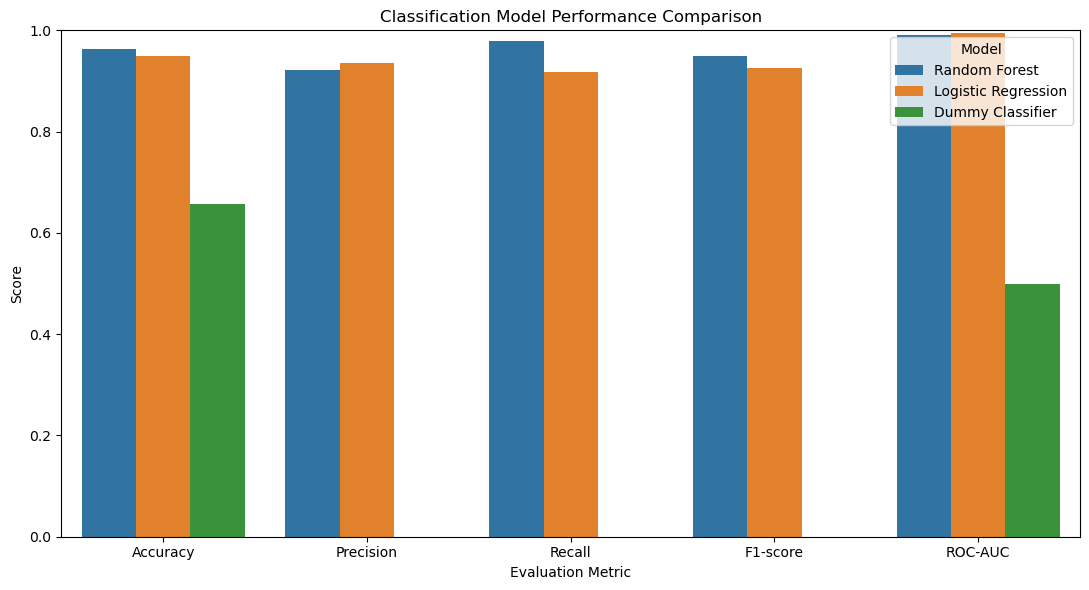

In [51]:
comparison_long = results_df.melt(
    id_vars="Model",
    value_vars=[
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC",
    ],
    var_name="Metric",
    value_name="Score",
)

plt.figure(figsize=(11, 6))

sns.barplot(
    data=comparison_long,
    x="Metric",
    y="Score",
    hue="Model"
)

plt.title("Classification Model Performance Comparison")
plt.xlabel("Evaluation Metric")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.legend(title="Model")
plt.tight_layout()
plt.show()

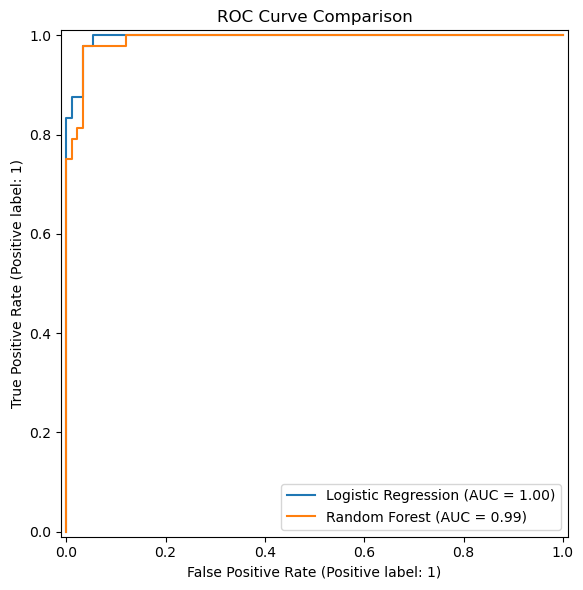

In [52]:
fig, ax = plt.subplots(figsize=(8, 6))

RocCurveDisplay.from_predictions(
    y_test,
    logistic_probabilities,
    name="Logistic Regression",
    ax=ax
)

RocCurveDisplay.from_predictions(
    y_test,
    random_forest_probabilities,
    name="Random Forest",
    ax=ax
)

plt.title("ROC Curve Comparison")
plt.tight_layout()
plt.show()

## 11. Random Forest Feature Importance

Random Forest provides feature-importance values that estimate how strongly
each transformed feature contributed to the model's decisions.

Feature importance indicates predictive contribution within this model. It
does not prove that a feature causes survival.

In [53]:
fitted_preprocessor = (
    random_forest_pipeline
    .named_steps["preprocessing"]
)

feature_names = (
    fitted_preprocessor
    .get_feature_names_out()
)

feature_importances = (
    random_forest_pipeline
    .named_steps["model"]
    .feature_importances_
)

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": feature_importances,
})

importance_df = importance_df.sort_values(
    by="importance",
    ascending=False
).reset_index(drop=True)

importance_df.head(10)

,feature,importance
0,num__Cell.size,0.326029
1,num__Cell.shape,0.205417
2,num__Bare.nuclei,0.157831
3,num__Normal.nucleoli,0.104491
4,num__Epith.c.size,0.073264
5,num__Bl.cromatin,0.064324
6,num__Cl.thickness,0.040136
7,num__Marg.adhesion,0.023047
8,num__Mitoses,0.005460


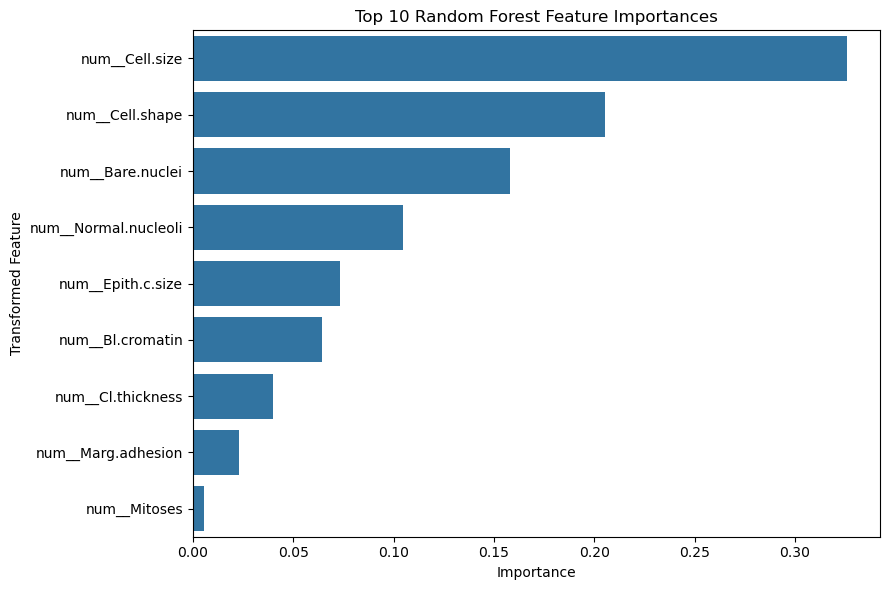

In [54]:
top_features = importance_df.head(10)

plt.figure(figsize=(9, 6))

sns.barplot(
    data=top_features,
    x="importance",
    y="feature"
)

plt.title("Top 10 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Transformed Feature")
plt.tight_layout()
plt.show()

## 12. Evaluation Interpretation

### Accuracy

Accuracy measures the proportion of all test examples classified correctly.

### Precision

Precision measures how many passengers predicted to survive actually
survived.

### Recall

Recall measures how many actual survivors were identified by the model.

### F1-score

F1-score balances precision and recall. It is the principal metric used for
the final model comparison.

### ROC-AUC

ROC-AUC measures the model's ability to rank survivors above non-survivors
across different classification thresholds.

### Confusion Matrix

The confusion matrix shows:

- true negatives: non-survivors correctly identified;
- false positives: non-survivors incorrectly predicted as survivors;
- false negatives: survivors incorrectly predicted as non-survivors;
- true positives: survivors correctly identified.

## 13. Final Conclusion

This project implemented a complete supervised-learning pipeline for Titanic
survival prediction.

The pipeline included:

- data inspection;
- exploratory data analysis;
- missing-value imputation;
- one-hot encoding;
- numerical feature scaling;
- a stratified train/test split;
- baseline evaluation;
- Logistic Regression;
- Random Forest classification;
- classification metrics;
- confusion matrices;
- ROC-AUC analysis;
- feature-importance analysis.

The baseline model achieved an F1-score of **[insert result]**.

Logistic Regression achieved:

- Accuracy: **[insert result]**
- Precision: **[insert result]**
- Recall: **[insert result]**
- F1-score: **[insert result]**
- ROC-AUC: **[insert result]**

Random Forest achieved:

- Accuracy: **[insert result]**
- Precision: **[insert result]**
- Recall: **[insert result]**
- F1-score: **[insert result]**
- ROC-AUC: **[insert result]**

Based primarily on F1-score, the selected model is
**[Logistic Regression or Random Forest]**.

It was selected because **[explain why using the metrics]**.

Both trained models should outperform the majority-class baseline. This
demonstrates that the passenger features contain useful predictive
information.

### Limitations

The project has several limitations:

1. The dataset is historical and relatively small.
2. Missing values require estimation.
3. The selected features do not capture every factor that influenced survival.
4. Feature importance does not demonstrate causation.
5. The model was evaluated using one train/test split rather than
   cross-validation.
6. Hyperparameter tuning was not performed during Week 3.

Future work could include cross-validation, hyperparameter tuning, additional
feature engineering, threshold adjustment, and Scikit-learn model pipelines
with more advanced evaluation.

## 14. Data Leakage Prevention

The project avoids preprocessing leakage by placing imputation, encoding,
and scaling inside Scikit-learn pipelines.

During `fit`, preprocessing parameters are learned only from `X_train`.

During prediction, the fitted preprocessing steps are applied to `X_test`
without being refitted.

Therefore, information from the test set is not used to train the models.